# JKO Flow and the Porous Medium Equation

## Mathematical Background

The **porous medium equation** (PME) is a nonlinear diffusion PDE of the form
$$
\partial_t \rho = \Delta(\rho^m), \quad m > 1,
$$
where $\rho(t,x) \geq 0$ is a density (or pressure) field. In one spatial dimension it becomes
$$
\partial_t \rho = \partial_{xx}(\rho^m).
$$

### Connection to Optimal Transport (JKO Scheme)

The PME can be interpreted as a **Wasserstein gradient flow** of the Rényi entropy
$$
\mathcal{E}_m[\rho] = \frac{1}{m-1} \int \rho^m \, dx.
$$
The JKO (Jordan–Kinderlehrer–Otto) scheme discretises this gradient flow as an iterated minimisation:
$$
\rho^{k+1} = \underset{\mu}{\arg\min} \left[ \frac{W_2(\mu, \rho^k)^2}{2\tau} + \mathcal{E}_m[\mu] \right],
$$
where $W_2$ is the $2$-Wasserstein distance and $\tau > 0$ is a time-step. This elegant variational structure unifies many diffusion equations within the framework of gradient flows on the space of probability measures.

### Finite-Difference Simulation

For illustration we use a direct **explicit finite-difference** discretisation:
$$
\rho_i^{n+1} = \rho_i^n + \frac{\Delta t}{\Delta x^2} \left[ (\rho_{i+1}^n)^m - 2(\rho_i^n)^m + (\rho_{i-1}^n)^m \right].
$$
Stability requires the CFL-like condition
$$
\Delta t \leq \frac{\Delta x^2}{4 \, m \, \|\rho^n\|_\infty^{m-1}},
$$
since the effective diffusivity at a point $x$ is $m\rho^{m-1}(x)$.

### What This Notebook Shows

- A Gaussian-mixture initial condition evolves according to the PME in 1D.
- We run the simulation long enough to see both **spreading** and **displacement** of mass.
- We compare four exponent values $m \in \{1.5, 2, 3, 4\}$: larger $m$ gives slower diffusion near the support boundary (finite speed of propagation) and a steeper, more compact profile at early times.

## Imports and Grid Setup

We use only `numpy` and `matplotlib`. The 1D spatial grid has $N = 400$ points on $[-1.5, 1.5]$, giving $\Delta x \approx 0.0075$. Figures are saved under the notebook-local folder.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Output folder: works whether executed from repo root or notebook directory
_here = Path("__file__").resolve().parent if "__file__" in dir() else Path(".")
OUT = Path(".")

# 1D spatial grid
N = 400
x = np.linspace(-1.5, 1.5, N)
dx = x[1] - x[0]

# Exponent values to study
M_VALUES = [1.5, 2.0, 3.0, 4.0]

# Number of time snapshots per simulation
N_SNAPS = 5

print(f"Grid: N={N}, dx={dx:.5f}, x in [{x[0]:.2f}, {x[-1]:.2f}]")

Grid: N=400, dx=0.00752, x in [-1.50, 1.50]


## Initial Condition

We choose an asymmetric **Gaussian mixture** placing two unequal peaks at different positions, so both spreading and displacement of mass are visible:
$$
\rho_0(x) \;\propto\; \exp\!\left(-\frac{(x+0.3)^2}{0.02}\right) + 0.7\,\exp\!\left(-\frac{(x-0.2)^2}{0.04}\right).
$$
We normalise so that $\int \rho_0 \, dx = 1$; the PME preserves total mass.

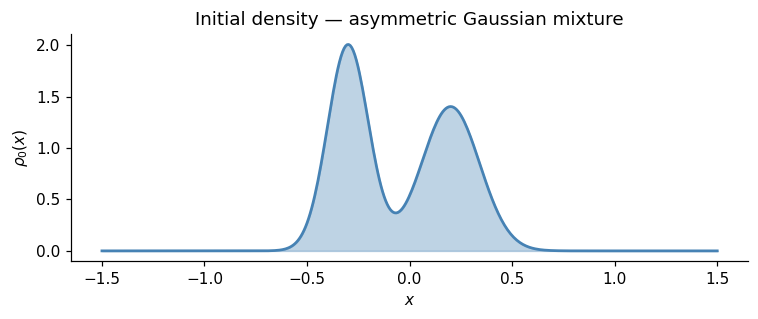

In [2]:
def make_rho0(x):
    """Gaussian-mixture initial density, normalised to unit mass."""
    rho = (np.exp(-((x + 0.3)**2) / 0.02)
           + 0.7 * np.exp(-((x - 0.2)**2) / 0.04))
    rho = np.maximum(rho, 0.0)
    rho /= rho.sum() * dx
    return rho

rho0 = make_rho0(x)

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(x, rho0, alpha=0.35, color="steelblue")
ax.plot(x, rho0, color="steelblue", lw=1.8)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\rho_0(x)$")
ax.set_title("Initial density — asymmetric Gaussian mixture")
fig.tight_layout()

## Explicit Finite-Difference Solver

The update rule is:
$$
\rho_i^{n+1} = \rho_i^n + \frac{\Delta t}{\Delta x^2}\bigl[(\rho_{i+1}^n)^m - 2(\rho_i^n)^m + (\rho_{i-1}^n)^m\bigr].
$$
Three safeguards are applied at each step:

1. **Non-negativity**: $\rho \leftarrow \max(\rho, 0)$.
2. **Mass renormalisation** to counteract floating-point drift.
3. **Zero-flux (Neumann) boundary conditions** via one-sided differences at the endpoints.

The time-step is chosen adaptively at each step via the parabolic CFL condition:
$$
\Delta t = \frac{\Delta x^2}{4 \, m \, \|\rho\|_\infty^{m-1}}.
$$

In [3]:
def run_pme_1d(x, m, n_steps, snap_steps):
    """
    Explicit finite-difference solver for the 1D porous medium equation.

    Parameters
    ----------
    x          : 1D spatial grid
    m          : exponent in rho^m  (m > 1)
    n_steps    : total number of explicit time steps
    snap_steps : sorted list of step indices at which to record snapshots

    Returns
    -------
    snaps : list of (rho_array, cumulative_time) at the requested steps
    """
    h = x[1] - x[0]
    rho = make_rho0(x)
    snap_set = set(snap_steps)
    snaps = []
    t = 0.0

    for k in range(n_steps):
        if k in snap_set:
            snaps.append((rho.copy(), t))

        # Adaptive CFL
        rho_max = rho.max()
        if rho_max < 1e-14:
            break
        dt = h**2 / (4.0 * m * rho_max**(m - 1.0))

        # Laplacian of rho^m with Neumann BC
        q = rho**m
        lap = np.empty_like(q)
        lap[1:-1] = (q[2:] - 2.0 * q[1:-1] + q[:-2]) / h**2
        lap[0]    = (q[1]  - q[0])  / h**2
        lap[-1]   = (q[-2] - q[-1]) / h**2

        rho = np.maximum(rho + dt * lap, 0.0)
        mass = rho.sum() * h
        if mass > 1e-14:
            rho /= mass
        t += dt

    # Append final state if we are short
    while len(snaps) < len(snap_steps):
        snaps.append((rho.copy(), t))

    return snaps

print("Solver ready.")

Solver ready.


## Running the Simulation for All Exponents

We run **4 000 explicit steps** for each $m \in \{1.5, 2, 3, 4\}$. Because the adaptive $\Delta t$ shrinks as $m$ grows (the diffusivity $m\rho^{m-1}$ at the peak forces a smaller step for the same $\Delta x$), the physical time reached differs across exponents: larger $m$ corresponds to shorter physical time per wall-clock second, but the profiles still show clear spreading.

Five snapshots evenly spaced over the 4 000 steps are stored per run.

In [4]:
N_STEPS = 4000
snap_steps = [int(k) for k in np.round(np.linspace(0, N_STEPS - 1, N_SNAPS))]

all_snaps = {}  # m -> list of (rho, t)

for m in M_VALUES:
    snaps = run_pme_1d(x, m=m, n_steps=N_STEPS, snap_steps=snap_steps)
    all_snaps[m] = snaps
    print(f"  m={m:.1f}: {len(snaps)} snapshots, final t = {snaps[-1][1]:.5f}")

print("Done.")

  m=1.5: 5 snapshots, final t = 0.03634
  m=2.0: 5 snapshots, final t = 0.02579


  m=3.0: 5 snapshots, final t = 0.01477
  m=4.0: 5 snapshots, final t = 0.00907
Done.


## Evolution Grid: One Row per Exponent

The main figure shows a $4 \times 5$ panel grid: each row is one exponent $m$, each column is a time snapshot. Key observations:

- **Spreading speed**: smaller $m$ (closer to linear heat equation) spreads fastest.
- **Profile shape**: larger $m$ yields flatter interiors and steeper edges — the hallmark of the Barenblatt self-similar solution
$$
\rho_B(t,x) = t^{-1/(m+1)} \left( C - k\,\frac{x^2}{t^{2/(m+1)}} \right)_+^{1/(m-1)},
$$
whose support grows like $t^{1/(m+1)}$.
- **Two-peak merger**: both Gaussian bumps gradually merge into a single broad distribution.

Saved snippet.png


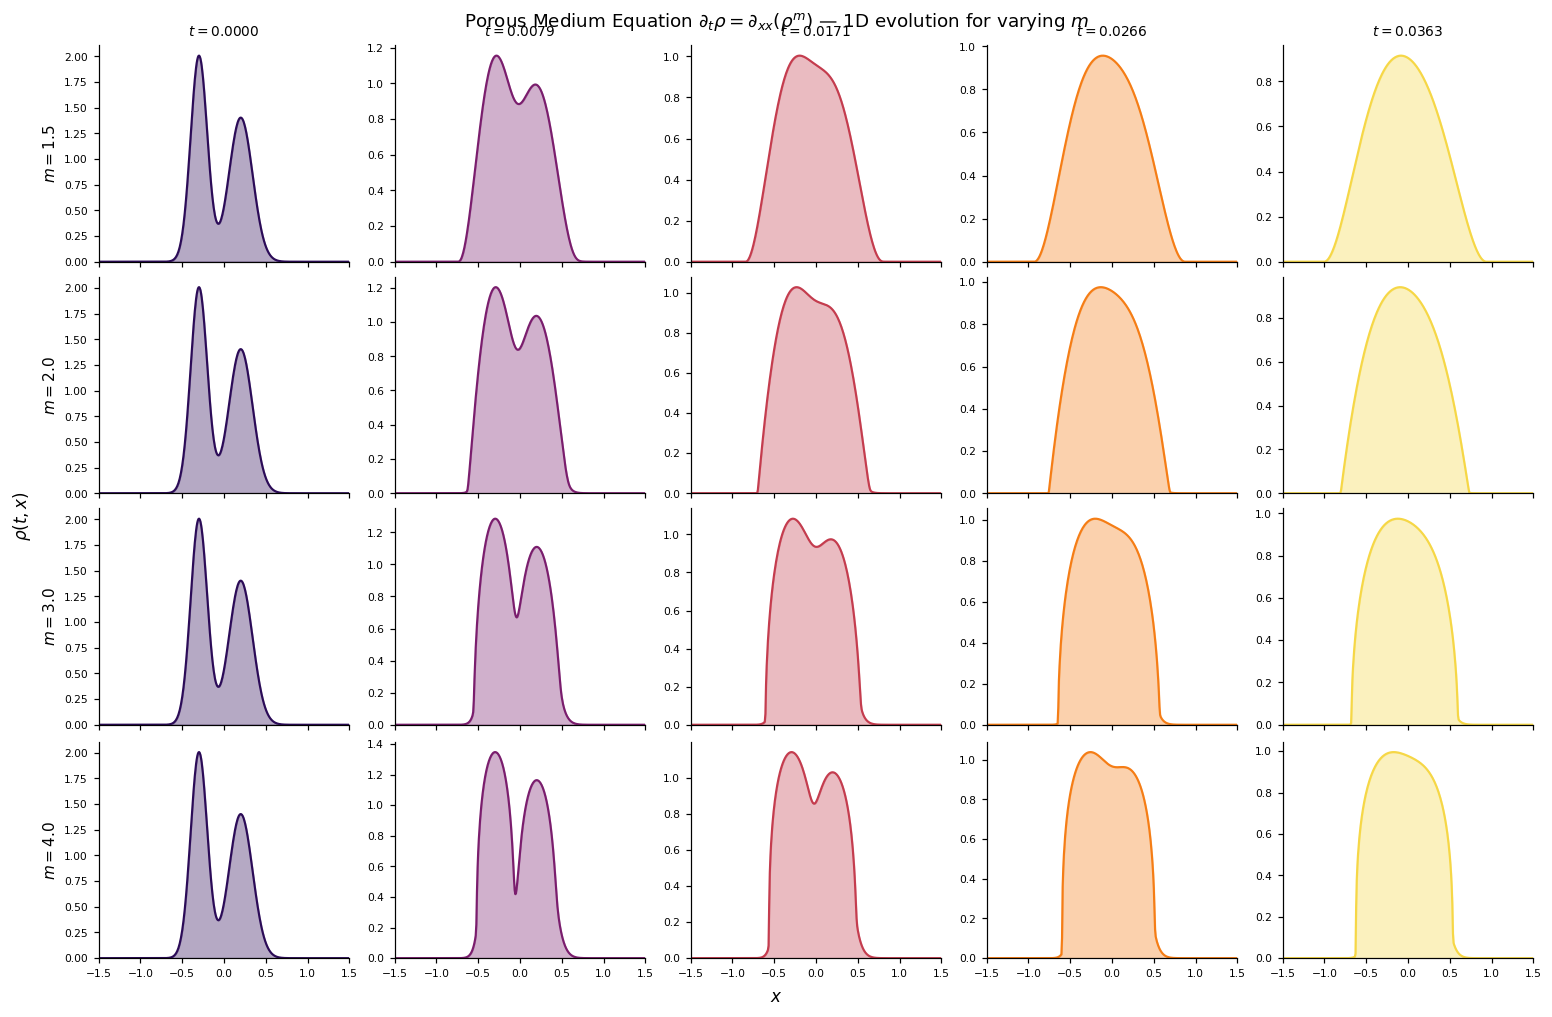

In [5]:
STATIC_SNAPSHOT = True

_cmap = plt.cm.inferno
_colors = [_cmap(v) for v in np.linspace(0.15, 0.9, N_SNAPS)]

fig, axes = plt.subplots(
    len(M_VALUES), N_SNAPS,
    figsize=(14, 9),
    sharex=True,
    constrained_layout=True,
)

for row, m in enumerate(M_VALUES):
    snaps = all_snaps[m]
    for col, (rho_s, t_s) in enumerate(snaps):
        ax = axes[row, col]
        ax.fill_between(x, rho_s, alpha=0.35, color=_colors[col])
        ax.plot(x, rho_s, color=_colors[col], lw=1.4)
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(bottom=0)
        if row == 0:
            ax.set_title(f"$t={t_s:.4f}$", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"$m={m}$", fontsize=10, labelpad=4)
        ax.tick_params(labelsize=7)

fig.supxlabel(r"$x$", fontsize=11)
fig.supylabel(r"$\rho(t,x)$", fontsize=11)
fig.suptitle(
    r"Porous Medium Equation $\partial_t\rho = \partial_{xx}(\rho^m)$"
    " — 1D evolution for varying $m$",
    fontsize=12, y=1.01,
)

fig.savefig(OUT / "snippet.png", bbox_inches="tight", dpi=130)
print("Saved snippet.png")

## Interactive Overlay: All Exponents at One Snapshot

The widget below overlays the four profiles $\rho(\cdot)$ for all values of $m$ at a user-selected snapshot index. Use the **slider** or **play** button to animate across snapshots. This view makes it easy to compare how the profile width and peak height differ across exponents at the same simulation step.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

_m_colors = {1.5: "#1f77b4", 2.0: "#ff7f0e", 3.0: "#2ca02c", 4.0: "#d62728"}

def _plot_overlay(snap_idx):
    fig, ax = plt.subplots(figsize=(8, 4))
    for m in M_VALUES:
        rho_s, t_s = all_snaps[m][snap_idx]
        ax.plot(x, rho_s, label=fr"$m={m},\ t={t_s:.4f}$",
                color=_m_colors[m], lw=1.8)
        ax.fill_between(x, rho_s, alpha=0.08, color=_m_colors[m])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$\rho(x)$")
    ax.set_title(f"All exponents at snapshot {snap_idx}")
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

_slider = widgets.IntSlider(
    value=0, min=0, max=N_SNAPS - 1, step=1,
    description="Snapshot:", continuous_update=False,
)
_play = widgets.Play(
    value=0, min=0, max=N_SNAPS - 1, step=1, interval=700,
)
widgets.jslink((_play, "value"), (_slider, "value"))
_out = widgets.interactive_output(_plot_overlay, {"snap_idx": _slider})
display(widgets.HBox([_play, _slider]), _out)

## Static Overlay Panel (Non-Interactive Fallback)

This cell provides the same comparison as the widget above in a static multi-panel layout suitable for automated execution. Each panel overlays all four exponents at the same snapshot index.

Notice that $m = 1.5$ (blue) produces the widest profile at every snapshot, while $m = 4$ (red) remains the most concentrated — consistent with the slower Barenblatt spreading rate $t^{1/(m+1)}$ for larger $m$.

Text(0.5, 0.98, 'All exponents overlaid at each snapshot')

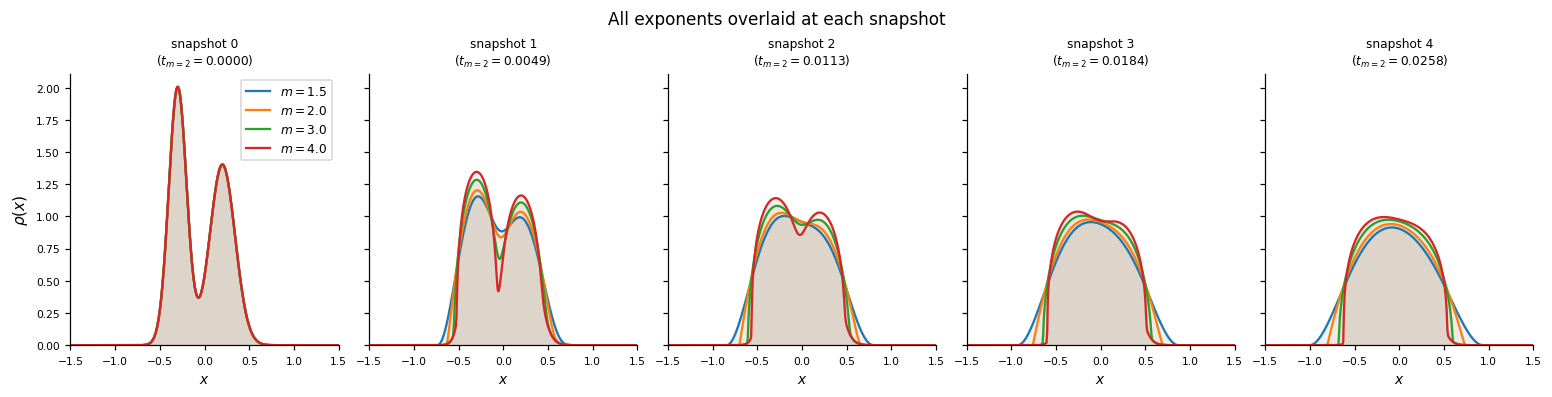

In [6]:
STATIC_SNAPSHOT = True

_m_colors = {1.5: "#1f77b4", 2.0: "#ff7f0e", 3.0: "#2ca02c", 4.0: "#d62728"}

fig2, axes2 = plt.subplots(
    1, N_SNAPS, figsize=(14, 3.5),
    sharey=True, constrained_layout=True,
)

for col in range(N_SNAPS):
    ax = axes2[col]
    for m in M_VALUES:
        rho_s, t_s = all_snaps[m][col]
        ax.plot(x, rho_s,
                label=f"$m={m}$" if col == 0 else None,
                color=_m_colors[m], lw=1.5)
        ax.fill_between(x, rho_s, alpha=0.08, color=_m_colors[m])
    # Use m=2 time as a reference label for the column
    ref_t = all_snaps[2.0][col][1]
    ax.set_title(f"snapshot {col}\n$(t_{{m=2}}={ref_t:.4f})$", fontsize=8)
    ax.set_xlabel(r"$x$", fontsize=9)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=7)

axes2[0].set_ylabel(r"$\rho(x)$", fontsize=10)
axes2[0].legend(fontsize=8, loc="upper right")
fig2.suptitle("All exponents overlaid at each snapshot", fontsize=11)

## Mass Conservation Check

A fundamental property of the PME is **mass conservation**:
$$
\frac{d}{dt} \int_{\mathbb{R}} \rho(t, x) \, dx = 0.
$$
We verify numerically that the discrete scheme preserves total mass (up to floating-point precision) across all snapshots and all exponent values.

In [7]:
STATIC_SNAPSHOT = True

header = f"{'m':>5}  " + "  ".join(f"snap{i}" for i in range(N_SNAPS))
print("Mass at each snapshot (target: 1.000000):")
print(header)
for m in M_VALUES:
    masses = [rho_s.sum() * dx for rho_s, _ in all_snaps[m]]
    row = "  ".join(f"{v:.6f}" for v in masses)
    print(f"{m:>5.1f}  {row}")

Mass at each snapshot (target: 1.000000):
    m  snap0  snap1  snap2  snap3  snap4
  1.5  1.000000  1.000000  1.000000  1.000000  1.000000
  2.0  1.000000  1.000000  1.000000  1.000000  1.000000
  3.0  1.000000  1.000000  1.000000  1.000000  1.000000
  4.0  1.000000  1.000000  1.000000  1.000000  1.000000


## Takeaways

- The porous medium equation $\partial_t \rho = \partial_{xx}(\rho^m)$ is a nonlinear diffusion model whose effective diffusivity $m\rho^{m-1}$ vanishes at the boundary of the support, leading to **finite speed of propagation** for $m > 1$.
- As $m$ increases, profiles become flatter in the interior and sharper at the edges — approaching a "mesa" shape — and the support expands more slowly (rate $\sim t^{1/(m+1)}$).
- The **JKO variational structure** (Wasserstein gradient flow of the Rényi entropy) provides a unified framework: the PME is the gradient flow of $\mathcal{E}_m[\rho] = \tfrac{1}{m-1}\int \rho^m\,dx$ with respect to the $W_2$ metric.
- The explicit finite-difference scheme used here is simple to implement but requires an adaptive time-step. Implicit or semi-implicit schemes are preferable for large $m$ or long time horizons.
- A Gaussian-mixture initial condition illustrates both **spreading** and **merging** of mass over time, with the dynamics strongly dependent on $m$.

## Bibliography

- R. Jordan, D. Kinderlehrer, F. Otto, *The variational formulation of the Fokker–Planck equation*, SIAM Journal on Mathematical Analysis, 29(1):1–17, 1998.
- J. L. Vázquez, *The Porous Medium Equation: Mathematical Theory*, Oxford University Press, 2007.
- C. Villani, *Topics in Optimal Transportation*, AMS Graduate Studies in Mathematics, 2003.
- F. Otto, *The geometry of dissipative evolution equations: the porous medium equation*, Comm. Partial Differential Equations, 26(1–2):101–174, 2001.
- G. Peyré, M. Cuturi, *Computational Optimal Transport*, Foundations and Trends in Machine Learning, 11(5–6):355–607, 2019.